# HANZE — floods and their impacts, in five minutes

[HANZE](https://naturalhazards.eu/) (Historical Analysis of Natural Hazards in Europe) is the
**observed** record of European flood events and their impacts — real floods since 1870, each with its
fatalities, persons affected, area flooded and economic losses. This is the observed hazard → loss side of
the flood chain: the yardstick a modelled event set is validated against.

This notebook pulls German and Dutch flood events straight from HANZE's pinned Zenodo release
(CC-BY-4.0, no credentials), looks at the loss and fatality distribution, and maps the affected NUTS-3
regions. Everything runs through the unified `EarthLens` facade.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from earthlens.core import EarthLens

# A stable scratch directory keeps the small (~3 MB) source files cached between runs.
OUT = Path(tempfile.gettempdir()) / "earthlens-hanze-demo"
OUT.mkdir(exist_ok=True)

2026-08-09 19:19:16 | INFO | pyramids.base.config | Logging is configured.


## 1. Pull the events

`hanze` is a **tabular** backend: `download()` returns a `pandas.DataFrame`, one row per historical flood,
with HANZE's own documented columns. We select Germany and the Netherlands over 1950–2020 with the
`country=` / `start=` / `end=` facets — no `variables` needed.

In [2]:
events = EarthLens(
    "hanze",
    start="1950",
    end="2020",
    country=["DE", "NL"],
    path=str(OUT),
).download(progress_bar=False)

print(f"{len(events)} flood events for DE + NL, 1950-2020")
events[
    ["Country code", "Year", "Type", "Fatalities", "Persons affected", "Losses (real value)"]
].head(10)

2026-08-09 19:19:17.793 | INFO     | earthlens.hanze.backend:_download_file:367 - HANZE: downloading HANZE_events_v3_0_1b.csv (record 20478847).


2026-08-09 19:19:18.223 | INFO     | earthlens.hanze.backend:_log_citation:638 - HANZE source citation: Paprotny, D. (2024). HANZE (Historical Analysis of Natural Hazards in Europe) v3.0.1-beta. Zenodo. https://doi.org/10.5281/zenodo.8410025. Licensed CC-BY-4.0.


2026-08-09 19:19:18.231 | INFO     | earthlens.hanze.backend:download:589 - HANZE: 102 event(s) written to C:\Users\main\AppData\Local\Temp\earthlens-hanze-demo\hanze_events-728adf3f.csv.


102 flood events for DE + NL, 1950-2020


,Country code,Year,Type,Fatalities,Persons affected,Losses (real value)
0,DE,1954,River,12.0,9000.0,7.208477e+08
1,DE,1954,River,0.0,NaN,6.487629e+06
2,DE,1954,River,2.0,NaN,NaN
3,DE,1955,Flash,7.0,NaN,NaN
4,DE,1956,River,0.0,NaN,5.857161e+08
5,DE,1957,Flash,0.0,NaN,3.352730e+08
6,DE,1958,River,4.0,NaN,1.629952e+08
7,DE,1961,River,9.0,NaN,NaN
8,DE,1962,Coastal,347.0,30000.0,6.874424e+09
9,DE,1965,Flash,16.0,NaN,NaN


## 2. What kind of floods, and how damaging?

The `Type` column is one of `River`, `Flash`, `Coastal`, or `River/Coastal`. Let's count the events by
type, then look at the distribution of inflation-adjusted (2025 €) losses. Losses are reported values, not
exposure-normalised — see the backend's introduction page for why that distinction matters.

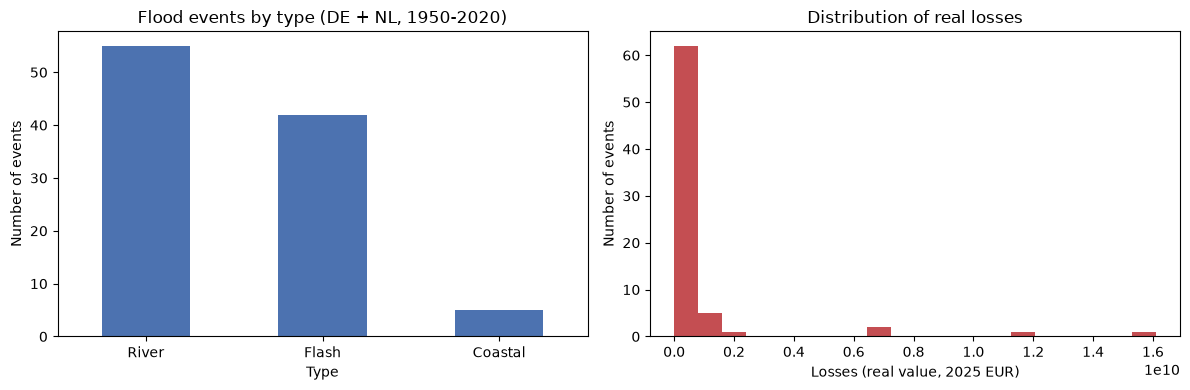

Total recorded fatalities: 2,459
Deadliest single event: 1,835 fatalities


In [3]:
losses = pd.to_numeric(events["Losses (real value)"], errors="coerce")
fatalities = pd.to_numeric(events["Fatalities"], errors="coerce")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

events["Type"].value_counts().plot.bar(ax=ax1, color="#4C72B0")
ax1.set_title("Flood events by type (DE + NL, 1950-2020)")
ax1.set_xlabel("Type")
ax1.set_ylabel("Number of events")
ax1.tick_params(axis="x", rotation=0)

valid = losses[losses > 0]
ax2.hist(valid, bins=20, color="#C44E52")
ax2.set_title("Distribution of real losses")
ax2.set_xlabel("Losses (real value, 2025 EUR)")
ax2.set_ylabel("Number of events")

fig.tight_layout()
plt.show()

print(f"Total recorded fatalities: {int(fatalities.sum()):,}")
print(f"Deadliest single event: {int(fatalities.max()):,} fatalities")

## 3. Where did they happen?

Pass `with_geometry=True` and `download()` returns a pyramids `FeatureCollection` of the **affected NUTS-3
regions** instead of the events table. Each event's `Regions affected (NUTS 3)` list is joined to the NUTS-3
boundary polygons; every affected region comes back once with an `n_events` count — a ready-made choropleth.
The polygons are reprojected from the release's ETRS89-LAEA (`EPSG:3035`) to WGS84 for you.

In [4]:
regions = EarthLens(
    "hanze",
    start="1950",
    end="2020",
    country=["DE", "NL"],
    with_geometry=True,
    path=str(OUT),
).download(progress_bar=False)

print(f"{len(regions)} affected NUTS-3 regions; CRS EPSG:{regions.crs.to_epsg()}")
regions[["nuts3_code", "region_name", "n_events"]].sort_values("n_events", ascending=False).head(10)

2026-08-09 19:19:19.217 | INFO     | earthlens.hanze.backend:_download_file:367 - HANZE: downloading Regions_v2024_simplified.zip (record 20478847).


2026-08-09 19:19:23.889 | INFO     | earthlens.hanze.backend:_log_citation:638 - HANZE source citation: Paprotny, D. (2024). HANZE (Historical Analysis of Natural Hazards in Europe) v3.0.1-beta. Zenodo. https://doi.org/10.5281/zenodo.8410025. Licensed CC-BY-4.0.


2026-08-09 19:19:23 | INFO | pyogrio._io | Created 301 records


2026-08-09 19:19:23.960 | INFO     | earthlens.hanze.backend:download:581 - HANZE: returned a FeatureCollection (301 affected region(s)).


301 affected NUTS-3 regions; CRS EPSG:4326


,nuts3_code,region_name,n_events
956,DE222,"Passau, Kreisfreie Stadt",11
957,DE228,"Passau, Landkreis",10
643,DEB11,"Koblenz, Kreisfreie Stadt",10
193,DEA22,"Bonn, Kreisfreie Stadt",10
897,DE27E,Oberallgäu,9
1258,DE21M,Traunstein,8
644,DEA23,"Köln, Kreisfreie Stadt",8
283,DEB1C,Cochem-Zell,7
1265,DEB21,"Trier, Kreisfreie Stadt",7
437,DE21D,Garmisch-Partenkirchen,7


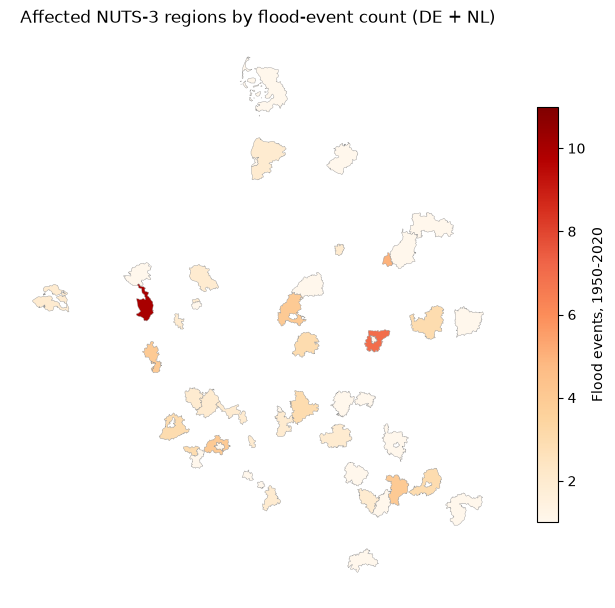

In [5]:
ax = regions.plot(
    column="n_events",
    cmap="OrRd",
    legend=True,
    edgecolor="0.6",
    linewidth=0.3,
    figsize=(8, 9),
    legend_kwds={"label": "Flood events, 1950-2020", "shrink": 0.6},
)
ax.set_title("Affected NUTS-3 regions by flood-event count (DE + NL)")
ax.set_axis_off()
plt.show()

## Recap

- `EarthLens("hanze", country=[...], start=, end=)` → a `DataFrame` of observed floods and their impacts.
- `with_geometry=True` → a `FeatureCollection` of the affected NUTS-3 regions, one per region with an
  `n_events` count, in WGS84.
- The data is HANZE **v3.0.1-beta** (pinned Zenodo record `20478847`, CC-BY-4.0) — cite Paprotny et al., and
  treat the figures as provisional.
- Losses are reported (nominal + inflation-adjusted real), **not** exposure-normalised.